# 05 — Shortlisting / Fit Predictor (Model B, Optional, Supervised)

Predicts whether a resume is a good "fit" for a specific job posting from engineered match
features (text similarity, skill overlap, experience match, title overlap).

**Important:** there is no public dataset of real hiring outcomes, so this model is trained
with *weak supervision* — pseudo-labels derived from percentile-ranked similarity + skill
overlap on random (resume, job) pairs. See the docstring in `src/models/fit_predictor.py` and
the README for the full explanation. Treat this as a demonstration of the modeling technique,
not a real shortlisting predictor.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

from src.data import load_data, preprocess
from src.models import recommender, fit_predictor
from src import config

## 1. Load resumes + job index

In [2]:
resumes_raw = load_data.load_resumes()
resumes_clean = preprocess.clean_resumes(resumes_raw)

job_corpus = pd.read_csv(config.JOB_CORPUS_CSV)
job_vectorizer, job_matrix = recommender.load_job_index()

## 2. Generate weak-supervised training pairs

In [3]:
pairs = fit_predictor.generate_training_pairs(resumes_clean, job_corpus, job_vectorizer, job_matrix, n_pairs=6000)
pairs['fit_label'].value_counts()

fit_label
0    4500
1    1500
Name: count, dtype: int64

In [11]:
pairs.describe()

,text_similarity,skill_overlap,experience_match,title_overlap,fit_label
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,0.031969,0.160491,0.464067,0.189997,0.250000
std,0.023998,0.258766,0.220160,0.234719,0.433049
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.013891,0.000000,0.500000,0.000000,0.000000
50%,0.027243,0.000000,0.500000,0.111111,0.000000
75%,0.045306,0.250000,0.500000,0.333333,0.250000
max,0.218231,1.000000,1.000000,1.000000,1.000000


## 3. Train & compare Logistic Regression vs Gradient Boosting

In [4]:
results = {}
for model_type in ['logreg', 'gboost']:
    model, metrics = fit_predictor.train_fit_predictor(pairs, model_type=model_type)
    results[model_type] = (model, metrics)
    print(f"{model_type:10s} auc={metrics['roc_auc']:.3f}  f1={metrics['f1']:.3f}  precision={metrics['precision']:.3f}  recall={metrics['recall']:.3f}")

logreg     auc=0.931  f1=0.730  precision=0.679  recall=0.790
gboost     auc=1.000  f1=0.998  precision=1.000  recall=0.997


## 4. Save the best model

In [5]:
best_type = max(results, key=lambda k: results[k][1]['roc_auc'])
model, metrics = results[best_type]
fit_predictor.save_fit_predictor(model)
print('Saved', best_type, 'to', config.FIT_PREDICTOR_MODEL)

Saved gboost to C:\Users\Srilatha Reddy\Downloads\smarthire\smarthire\models\fit_predictor.pkl


## 5. Feature importance (logreg coefficients)

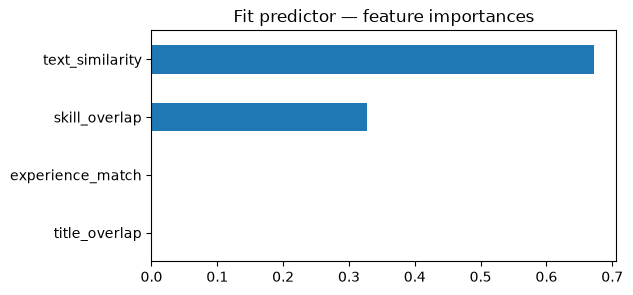

In [6]:
if best_type == 'logreg':
    coefs = pd.Series(model.coef_[0], index=fit_predictor.FEATURE_NAMES).sort_values()
    coefs.plot(kind='barh', figsize=(6,3))
    plt.title('Fit predictor — feature coefficients')
    plt.show()
else:
    importances = pd.Series(model.feature_importances_, index=fit_predictor.FEATURE_NAMES).sort_values()
    importances.plot(kind='barh', figsize=(6,3))
    plt.title('Fit predictor — feature importances')
    plt.show()